In [8]:
#get all the tables:
from db_setup import conn, currencyexchange, customer, date, product, sales, store
#instead of saving csv files in sql and then importing one by one
import pandas as pd

customer_summary=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_summary.parquet")
rfm=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\rfm.parquet")
customer_value_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_value_segments.parquet")
order_enriched=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\order_enriched.parquet")
customer_segments=pd.read_parquet(r"C:\Users\amyre\Desktop\Luke Barousse SQL Course\SQL + Contoso\saved_files\customer_segments.parquet")


why pareto and lorenz:

Lorenz curve

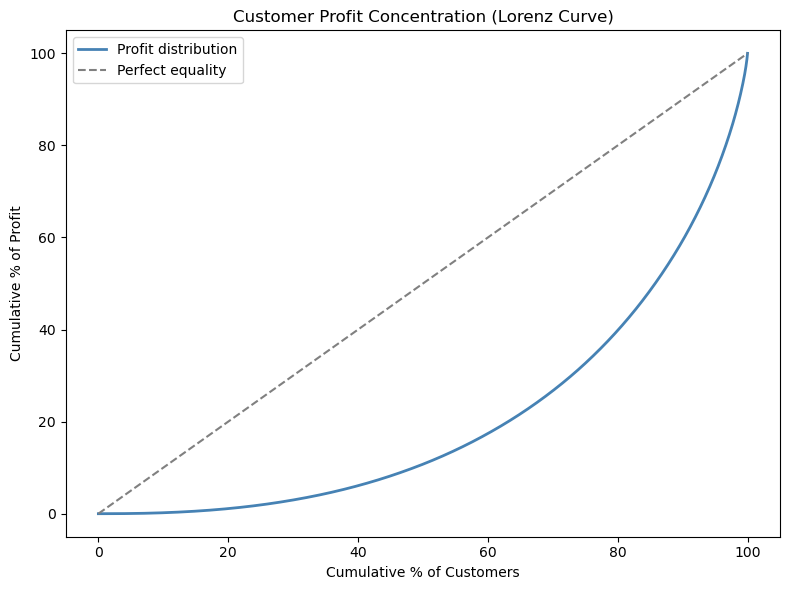

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

profits = customer_summary["lifetime_profit"].sort_values().values

cumulative_profit = np.cumsum(profits) / profits.sum()

cumulative_customers = np.arange(1, len(profits)+1) / len(profits)

plt.figure(figsize=(8,6))

plt.plot(
    cumulative_customers*100,
    cumulative_profit*100,
    color="steelblue",
    linewidth=2,
    label="Profit distribution"
)


plt.plot(
    [0,100],
    [0,100],
    linestyle="--",
    color="gray",
    label="Perfect equality"
)

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Profit")
plt.title("Customer Profit Concentration (Lorenz Curve)")

plt.legend()
plt.tight_layout()


Pareto equivalent

In [ ]:
pareto = customer_summary[["customerkey", "lifetime_profit"]].copy()

# sort profit desc
pareto = pareto.sort_values("lifetime_profit", ascending=False).reset_index(drop=True)



# create 100 equal-sized buckets like NTILE(100)
pareto["profit_bucket"] = pd.qcut(
    pareto.index + 1,
    q=100,
    labels=False
) + 1


def assign_tier(bucket):
    if bucket <= 1:
        return "Top 1%"
    elif bucket <= 5:
        return "Top 5%"
    elif bucket <= 10:
        return "Top 10%"
    elif bucket <= 20:
        return "Top 20%"
    else:
        return "Bottom 80%"

def assign_tier_order(bucket):
    if bucket <= 1:
        return 1
    elif bucket <= 5:
        return 2
    elif bucket <= 10:
        return 3
    elif bucket <= 20:
        return 4
    else:
        return 5

pareto["tier"] = pareto["profit_bucket"].apply(assign_tier)
pareto["tier_order"] = pareto["profit_bucket"].apply(assign_tier_order)

pareto_summary = (
    pareto
    .groupby(["tier", "tier_order"], as_index=False)
    .agg(
        customers=("customerkey", "count"),
        band_profit=("lifetime_profit", "sum")
    )
    .sort_values("tier_order")
)

pareto_summary["band_profit"] = pareto_summary["band_profit"].round(2)

total_profit = pareto_summary["band_profit"].sum()

pareto_summary["band_profit_share_pct"] = (
    pareto_summary["band_profit"] / total_profit * 100
).round(2)

pareto_summary["cumulative_profit_share_pct"] = (
    pareto_summary["band_profit"].cumsum() / total_profit * 100
).round(2)

pareto_summary = pareto_summary[[
    "tier",
    "customers",
    "band_profit",
    "band_profit_share_pct",
    "cumulative_profit_share_pct"
]]

print(pareto_summary)

         tier  customers  band_profit  band_profit_share_pct  \
1      Top 1%        495   9637581.29                   8.35   
4      Top 5%       1980  20593992.63                  17.85   
2     Top 10%       2474  16691714.84                  14.47   
3     Top 20%       4949  22516181.12                  19.51   
0  Bottom 80%      39589  45940134.15                  39.82   

   cumulative_profit_share_pct  
1                         8.35  
4                        26.20  
2                        40.67  
3                        60.18  
0                       100.00  
